In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, numpy as np, pandas as pd, ast, torch

BASE = "/content/drive/MyDrive/Colab Notebooks"
X_NPY = os.path.join(BASE, "X_ptbxl_500hz.npy")
META  = os.path.join(BASE, "ptbxl_database.csv")
SCP   = os.path.join(BASE, "scp_statements.csv")

print("X:", os.path.exists(X_NPY))
print("META:", os.path.exists(META))
print("SCP:", os.path.exists(SCP))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


X: True
META: True
SCP: True
Device: cuda


In [ ]:
!cp "{X_NPY}" /content/X_ptbxl_500hz.npy

X = np.load("/content/X_ptbxl_500hz.npy", mmap_mode="r")
print("X shape:", X.shape)  # expect (N,12,5000) or (N,5000,12)


X shape: (21799, 12, 5000)


In [ ]:
meta = pd.read_csv(META)
meta["scp_codes"] = meta["scp_codes"].apply(ast.literal_eval)

classes = ["NORM", "IMI", "ASMI", "LVH", "NDT", "LAFB"]
class_to_idx = {c:i for i,c in enumerate(classes)}

N = len(meta)
C = len(classes)

y = np.zeros((N, C), dtype=np.float32)
for i, codes in enumerate(meta["scp_codes"]):
    for code in codes.keys():
        if code in class_to_idx:
            y[i, class_to_idx[code]] = 1.0

print("Classes:", classes)
print("y shape:", y.shape)
print("Positive rate:", dict(zip(classes, y.mean(axis=0))))
assert X.shape[0] == y.shape[0] == len(meta)


Classes: ['NORM', 'IMI', 'ASMI', 'LVH', 'NDT', 'LAFB']
y shape: (21799, 6)
Positive rate: {'NORM': np.float32(0.43644205), 'IMI': np.float32(0.12275793), 'ASMI': np.float32(0.10812423), 'LVH': np.float32(0.097802654), 'NDT': np.float32(0.08371944), 'LAFB': np.float32(0.07445296)}


In [ ]:
from sklearn.model_selection import GroupShuffleSplit
import numpy as np

groups = meta["patient_id"].values
idx_all = np.arange(N)

gss = GroupShuffleSplit(test_size=0.2, random_state=42)
train_val_idx, test_idx = next(gss.split(idx_all, y, groups))

gss2 = GroupShuffleSplit(test_size=0.25, random_state=42)
train_rel, val_rel = next(gss2.split(train_val_idx, y[train_val_idx], groups[train_val_idx]))

train_idx = train_val_idx[train_rel]
val_idx   = train_val_idx[val_rel]

print("train/val/test:", len(train_idx), len(val_idx), len(test_idx))

train_p = set(groups[train_idx]); val_p = set(groups[val_idx]); test_p = set(groups[test_idx])
print("Overlap train-val:", len(train_p & val_p))
print("Overlap train-test:", len(train_p & test_p))
print("Overlap val-test:", len(val_p & test_p))


train/val/test: 13121 4302 4376
Overlap train-val: 0
Overlap train-test: 0
Overlap val-test: 0


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class PTBXLDatasetLSTM(Dataset):
    def __init__(self, X_memmap, y_array, indices, normalize=True, downsample=5):
        self.X = X_memmap
        self.y = y_array
        self.indices = np.asarray(indices)
        self.normalize = normalize
        self.downsample = downsample

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        x = self.X[idx].astype(np.float32)

        # ensure (12,5000)
        if x.shape == (5000, 12):
            x = x.T  # -> (12,5000)

        # downsample in time: (12,5000) -> (12,1000) if downsample=5
        if self.downsample and self.downsample > 1:
            x = x[:, ::self.downsample]

        # per-lead z-score
        if self.normalize:
            mean = x.mean(axis=1, keepdims=True)
            std  = x.std(axis=1, keepdims=True) + 1e-6
            x = (x - mean) / std

        # LSTM expects (T, features) => (time, 12)
        x = x.T  # (T, 12)

        y = self.y[idx].astype(np.float32)
        return torch.from_numpy(x), torch.from_numpy(y)

batch_size = 32
downsample = 5  # 5000 -> 1000 time steps

train_ds = PTBXLDatasetLSTM(X, y, train_idx, downsample=downsample)
val_ds   = PTBXLDatasetLSTM(X, y, val_idx,   downsample=downsample)
test_ds  = PTBXLDatasetLSTM(X, y, test_idx,  downsample=downsample)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

xb, yb = next(iter(train_loader))
print("batch x:", xb.shape, "batch y:", yb.shape)  # (B,T,12), (B,6)


batch x: torch.Size([32, 1000, 12]) batch y: torch.Size([32, 6])


In [ ]:
import torch.nn as nn

class ECGBiLSTM(nn.Module):
    def __init__(self, n_classes, input_size=12, hidden_size=128, num_layers=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(hidden_size * 2, n_classes)

    def forward(self, x):
        # x: (B, T, 12)
        out, _ = self.lstm(x)           # (B, T, 2H)
        pooled = out.mean(dim=1)        # mean pooling over time => (B, 2H)
        pooled = self.dropout(pooled)
        return self.head(pooled)        # (B, C)

model = ECGBiLSTM(n_classes=y.shape[1], hidden_size=128, num_layers=1, dropout=0.2).to(device)
print(model)


ECGBiLSTM(
  (lstm): LSTM(12, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (head): Linear(in_features=256, out_features=6, bias=True)
)


In [ ]:
!pip install -U sympy==1.14.0


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 31.0 MB/s eta 0:00:00
  Attempting uninstall: sympy
    Found existing installation: sympy 1.11.1
    Uninstalling sympy-1.11.1:
      Successfully uninstalled sympy-1.11.1


In [ ]:
import time
import numpy as np
from sklearn.metrics import roc_auc_score

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def sigmoid_np(x):
    return 1 / (1 + np.exp(-x))

def macro_auroc(y_true, probs):
    aucs = []
    for c in range(y_true.shape[1]):
        if len(np.unique(y_true[:, c])) < 2:
            aucs.append(np.nan)
        else:
            aucs.append(roc_auc_score(y_true[:, c], probs[:, c]))
    return float(np.nanmean(aucs)), aucs

def run_epoch(loader, train=False):
    model.train() if train else model.eval()
    total_loss = 0.0
    all_logits, all_y = [], []

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)  # (B,T,12)
        yb = yb.to(device, non_blocking=True)

        if train:
            optimizer.zero_grad()

        logits = model(xb)
        loss = criterion(logits, yb)

        if train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * xb.size(0)
        all_logits.append(logits.detach().cpu().numpy())
        all_y.append(yb.detach().cpu().numpy())

    all_logits = np.concatenate(all_logits, axis=0)
    all_y = np.concatenate(all_y, axis=0)
    return total_loss / len(loader.dataset), all_logits, all_y


# ----------------------------
# Train EXACTLY 30 epochs + timing summary
# ----------------------------
best_val_loss = float("inf")
best_path = "/content/best_lstm_6labels.pt"
epochs = 30   # ✅ exactly 40 epochs

start_time = time.time()
epochs_trained = 0

for epoch in range(1, epochs + 1):
    epoch_start = time.time()
    epochs_trained = epoch

    tr_loss, _, _ = run_epoch(train_loader, train=True)
    va_loss, va_logits, va_y = run_epoch(val_loader, train=False)

    va_probs = sigmoid_np(va_logits)
    va_macro_auc, _ = macro_auroc(va_y, va_probs)

    # Save best model (optional but recommended)
    if va_loss < best_val_loss:
        best_val_loss = va_loss
        torch.save(model.state_dict(), best_path)
        status = "✅ saved"
    else:
        status = "—"

    epoch_time = time.time() - epoch_start

    print(
        f"Epoch {epoch:02d} | "
        f"train {tr_loss:.4f} | "
        f"val {va_loss:.4f} | "
        f"val macro-AUROC {va_macro_auc:.4f} | "
        f"time {epoch_time:.1f}s | "
        f"{status}"
    )

end_time = time.time()
total_time = end_time - start_time

hours = int(total_time // 3600)
minutes = int((total_time % 3600) // 60)
seconds = int(total_time % 60)

print("\n===== TRAINING SUMMARY =====")
print(f"Total epochs trained : {epochs_trained}")
print(f"Total training time  : {hours}h {minutes}m {seconds}s")
print("Best model saved:", best_path)
print("Best val loss:", best_val_loss)


Epoch 01 | train 0.3367 | val 0.2900 | val macro-AUROC 0.8242 | time 7.0s | ✅ saved
Epoch 02 | train 0.2740 | val 0.2634 | val macro-AUROC 0.8600 | time 6.3s | ✅ saved
Epoch 03 | train 0.2846 | val 0.2887 | val macro-AUROC 0.8338 | time 6.1s | —
Epoch 04 | train 0.2709 | val 0.2633 | val macro-AUROC 0.8603 | time 6.1s | ✅ saved
Epoch 05 | train 0.2590 | val 0.2519 | val macro-AUROC 0.8732 | time 6.1s | ✅ saved
Epoch 06 | train 0.2559 | val 0.2546 | val macro-AUROC 0.8718 | time 6.1s | —
Epoch 07 | train 0.2617 | val 0.2533 | val macro-AUROC 0.8727 | time 6.1s | —
Epoch 08 | train 0.2579 | val 0.2463 | val macro-AUROC 0.8816 | time 6.1s | ✅ saved
Epoch 09 | train 0.2408 | val 0.2349 | val macro-AUROC 0.8888 | time 6.1s | ✅ saved
Epoch 10 | train 0.2372 | val 0.2360 | val macro-AUROC 0.8889 | time 6.1s | —
Epoch 11 | train 0.2336 | val 0.2308 | val macro-AUROC 0.8971 | time 6.1s | ✅ saved
Epoch 12 | train 0.2256 | val 0.2199 | val macro-AUROC 0.9042 | time 6.1s | ✅ saved
Epoch 13 | train

In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def sigmoid_np(x):
    return 1 / (1 + np.exp(-x))

def macro_auroc(y_true, probs):
    aucs = []
    for c in range(y_true.shape[1]):
        if len(np.unique(y_true[:, c])) < 2:
            aucs.append(np.nan)
        else:
            aucs.append(roc_auc_score(y_true[:, c], probs[:, c]))
    return float(np.nanmean(aucs)), aucs

def run_epoch(loader, train=False):
    model.train() if train else model.eval()
    total_loss = 0.0
    all_logits, all_y = [], []

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)  # (B,T,12)
        yb = yb.to(device, non_blocking=True)

        if train:
            optimizer.zero_grad()

        logits = model(xb)
        loss = criterion(logits, yb)

        if train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * xb.size(0)
        all_logits.append(logits.detach().cpu().numpy())
        all_y.append(yb.detach().cpu().numpy())

    all_logits = np.concatenate(all_logits, axis=0)
    all_y = np.concatenate(all_y, axis=0)
    return total_loss / len(loader.dataset), all_logits, all_y

best_val_loss = float("inf")
best_path = "/content/best_lstm_6labels.pt"

epochs = 40
patience = 6
wait = 0

for epoch in range(1, epochs + 1):
    tr_loss, _, _ = run_epoch(train_loader, train=True)
    va_loss, va_logits, va_y = run_epoch(val_loader, train=False)

    va_probs = sigmoid_np(va_logits)
    va_macro_auc, _ = macro_auroc(va_y, va_probs)

    if va_loss < best_val_loss:
        best_val_loss = va_loss
        wait = 0
        torch.save(model.state_dict(), best_path)
        status = "✅ saved"
    else:
        wait += 1
        status = f"wait {wait}/{patience}"

    print(f"Epoch {epoch:02d} | train {tr_loss:.4f} | val {va_loss:.4f} | val macro-AUROC {va_macro_auc:.4f} | {status}")

    if wait >= patience:
        print("🛑 Early stopping triggered.")
        break

print("✅ Best LSTM saved:", best_path, "| best val loss:", best_val_loss)


KeyboardInterrupt: 

In [ ]:
model.load_state_dict(torch.load(best_path, map_location=device))

te_loss, te_logits, te_y = run_epoch(test_loader, train=False)
te_probs = sigmoid_np(te_logits)

te_macro_auc, te_aucs = macro_auroc(te_y, te_probs)

print("\nTEST loss:", te_loss)
print("TEST macro-AUROC:", te_macro_auc)
print("Per-class AUROC:")
for cls, aucv in zip(classes, te_aucs):
    print(f"  {cls:6s}: {aucv}")



TEST loss: 0.18632866352306204
TEST macro-AUROC: 0.9337111686928578
Per-class AUROC:
  NORM  : 0.9448022534353469
  IMI   : 0.9404182460956122
  ASMI  : 0.9653613117447711
  LVH   : 0.8776543155130879
  NDT   : 0.892764906694013
  LAFB  : 0.9812659786743158


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

threshold = 0.5
y_true = te_y.astype(int)
y_pred = (te_probs >= threshold).astype(int)

subset_acc = accuracy_score(y_true, y_pred)

macro_precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
macro_recall    = recall_score(y_true, y_pred, average="macro", zero_division=0)
macro_f1        = f1_score(y_true, y_pred, average="macro", zero_division=0)

print("\n=== TEST METRICS (threshold=0.5) ===")
print(f"Subset Accuracy : {subset_acc:.4f}")
print(f"Macro Precision : {macro_precision:.4f}")
print(f"Macro Recall    : {macro_recall:.4f}")
print(f"Macro F1-score  : {macro_f1:.4f}")

print("\n=== Per-class Precision, Recall, and F1-Score ===")
for i, cls in enumerate(classes):
    precision = precision_score(y_true[:, i], y_pred[:, i], zero_division=0)
    recall    = recall_score(y_true[:, i], y_pred[:, i], zero_division=0)
    f1        = f1_score(y_true[:, i], y_pred[:, i], zero_division=0)
    support   = int(y_true[:, i].sum())
    print(f"{cls:6s} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1-score: {f1:.4f} | Positive samples: {support}")



=== TEST METRICS (threshold=0.5) ===
Subset Accuracy : 0.6449
Macro Precision : 0.7284
Macro Recall    : 0.5238
Macro F1-score  : 0.5840

=== Per-class Precision, Recall, and F1-Score ===
NORM   | Precision: 0.8222 | Recall: 0.8983 | F1-score: 0.8585 | Positive samples: 1946
IMI    | Precision: 0.7479 | Recall: 0.5009 | F1-score: 0.6000 | Positive samples: 527
ASMI   | Precision: 0.8198 | Recall: 0.6121 | F1-score: 0.7009 | Positive samples: 446
LVH    | Precision: 0.6485 | Recall: 0.2655 | F1-score: 0.3768 | Positive samples: 403
NDT    | Precision: 0.5618 | Recall: 0.1351 | F1-score: 0.2179 | Positive samples: 370
LAFB   | Precision: 0.7700 | Recall: 0.7310 | F1-score: 0.7500 | Positive samples: 316


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

threshold = 0.5
y_true = te_y.astype(int)
y_pred = (te_probs >= threshold).astype(int)

# 1) Subset accuracy (very strict: all labels must match)
subset_acc = accuracy_score(y_true, y_pred)

# 2) "Normal" accuracy for multi-label: element-wise accuracy
label_accuracy = (y_true == y_pred).mean()

# 3) Macro label accuracy: average of per-class accuracies
per_class_accuracy = [(y_true[:, i] == y_pred[:, i]).mean() for i in range(len(classes))]
macro_label_accuracy = float(np.mean(per_class_accuracy))

macro_precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
macro_recall    = recall_score(y_true, y_pred, average="macro", zero_division=0)
macro_f1        = f1_score(y_true, y_pred, average="macro", zero_division=0)

print("\n=== TEST METRICS (threshold=0.5) ===")
print(f"Subset Accuracy (exact match)      : {subset_acc:.4f}")
print(f"Label Accuracy (element-wise)      : {label_accuracy:.4f}")      # ✅ normal accuracy
print(f"Macro Label Accuracy (avg classes) : {macro_label_accuracy:.4f}") # optional
print(f"Macro Precision                    : {macro_precision:.4f}")
print(f"Macro Recall                       : {macro_recall:.4f}")
print(f"Macro F1-score                     : {macro_f1:.4f}")

print("\n=== Per-class Precision, Recall, and F1-Score ===")
for i, cls in enumerate(classes):
    precision = precision_score(y_true[:, i], y_pred[:, i], zero_division=0)
    recall    = recall_score(y_true[:, i], y_pred[:, i], zero_division=0)
    f1        = f1_score(y_true[:, i], y_pred[:, i], zero_division=0)
    acc       = (y_true[:, i] == y_pred[:, i]).mean()
    support   = int(y_true[:, i].sum())
    print(f"{cls:6s} | Accuracy: {acc:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1-score: {f1:.4f} | Positive samples: {support}")



=== TEST METRICS (threshold=0.5) ===
Subset Accuracy (exact match)      : 0.6449
Label Accuracy (element-wise)      : 0.9228
Macro Label Accuracy (avg classes) : 0.9228
Macro Precision                    : 0.7284
Macro Recall                       : 0.5238
Macro F1-score                     : 0.5840

=== Per-class Precision, Recall, and F1-Score ===
NORM   | Accuracy: 0.8684 | Precision: 0.8222 | Recall: 0.8983 | F1-score: 0.8585 | Positive samples: 1946
IMI    | Accuracy: 0.9196 | Precision: 0.7479 | Recall: 0.5009 | F1-score: 0.6000 | Positive samples: 527
ASMI   | Accuracy: 0.9468 | Precision: 0.8198 | Recall: 0.6121 | F1-score: 0.7009 | Positive samples: 446
LVH    | Accuracy: 0.9191 | Precision: 0.6485 | Recall: 0.2655 | F1-score: 0.3768 | Positive samples: 403
NDT    | Accuracy: 0.9180 | Precision: 0.5618 | Recall: 0.1351 | F1-score: 0.2179 | Positive samples: 370
LAFB   | Accuracy: 0.9648 | Precision: 0.7700 | Recall: 0.7310 | F1-score: 0.7500 | Positive samples: 316


In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

supports = np.array([y_true[:, i].sum() for i in range(len(classes))])
weights = supports / supports.sum()

prec_list, rec_list, f1_list = [], [], []

for i in range(len(classes)):
    prec = precision_score(y_true[:, i], y_pred[:, i], zero_division=0)
    rec  = recall_score(y_true[:, i], y_pred[:, i], zero_division=0)
    f1   = f1_score(y_true[:, i], y_pred[:, i], zero_division=0)

    prec_list.append(prec)
    rec_list.append(rec)
    f1_list.append(f1)

prec_list = np.array(prec_list)
rec_list  = np.array(rec_list)
f1_list   = np.array(f1_list)

weighted_precision = np.sum(weights * prec_list)
weighted_recall    = np.sum(weights * rec_list)
weighted_f1        = np.sum(weights * f1_list)

print("\n=== LABEL-WISE WEIGHTED AVERAGE METRICS ===")
print(f"Weighted Precision : {weighted_precision:.4f}")
print(f"Weighted Recall    : {weighted_recall:.4f}")
print(f"Weighted F1-score  : {weighted_f1:.4f}")




=== LABEL-WISE WEIGHTED AVERAGE METRICS ===
Weighted Precision : 0.7665
Weighted Recall    : 0.6669
Weighted F1-score  : 0.6909


In [ ]:
import time

start_time = time.time()


In [ ]:
end_time = time.time()
total_time = end_time - start_time

hours = int(total_time // 3600)
minutes = int((total_time % 3600) // 60)
seconds = int(total_time % 60)

print(f"\n⏱️ Training Time: {hours}h {minutes}m {seconds}s")


⏱️ Training Time: 0h 0m 14s


In [ ]:
for epoch in range(1, epochs + 1):
    epoch_start = time.time()

    tr_loss, _, _ = run_epoch(train_loader, train=True)
    va_loss, va_logits, va_y = run_epoch(val_loader, train=False)

    epoch_time = time.time() - epoch_start

    print(
        f"Epoch {epoch:02d} | "
        f"train {tr_loss:.4f} | "
        f"val {va_loss:.4f} | "
        f"time {epoch_time:.1f}s"
    )

Epoch 01 | train 0.1898 | val 0.2002 | time 6.3s
Epoch 02 | train 0.1899 | val 0.2015 | time 6.3s
Epoch 03 | train 0.1912 | val 0.2007 | time 6.1s
Epoch 04 | train 0.1871 | val 0.2006 | time 6.1s
Epoch 05 | train 0.1853 | val 0.2048 | time 6.1s
Epoch 06 | train 0.1858 | val 0.2022 | time 6.1s
Epoch 07 | train 0.1883 | val 0.2024 | time 6.2s
Epoch 08 | train 0.1832 | val 0.1984 | time 6.1s
Epoch 09 | train 0.1906 | val 0.2063 | time 6.1s
Epoch 10 | train 0.1901 | val 0.2012 | time 6.1s
Epoch 11 | train 0.1886 | val 0.2090 | time 6.1s
Epoch 12 | train 0.1943 | val 0.2258 | time 6.1s
Epoch 13 | train 0.2021 | val 0.1999 | time 6.1s
Epoch 14 | train 0.1894 | val 0.2362 | time 6.2s
Epoch 15 | train 0.1966 | val 0.1989 | time 6.2s
Epoch 16 | train 0.1880 | val 0.2033 | time 6.1s
Epoch 17 | train 0.1852 | val 0.1997 | time 6.1s
Epoch 18 | train 0.1836 | val 0.2000 | time 6.1s
Epoch 19 | train 0.1882 | val 0.2049 | time 6.1s
Epoch 20 | train 0.2071 | val 0.2052 | time 6.1s
Epoch 21 | train 0.1

In [ ]:
end_time = time.time()
total_time = end_time - start_time

hours = int(total_time // 3600)
minutes = int((total_time % 3600) // 60)
seconds = int(total_time % 60)

print("\n===== TRAINING SUMMARY =====")
print(f"Total epochs trained : {epochs_trained}")
print(f"Total training time  : {hours}h {minutes}m {seconds}s")




===== TRAINING SUMMARY =====
Total epochs trained : 30
Total training time  : 0h 5m 23s


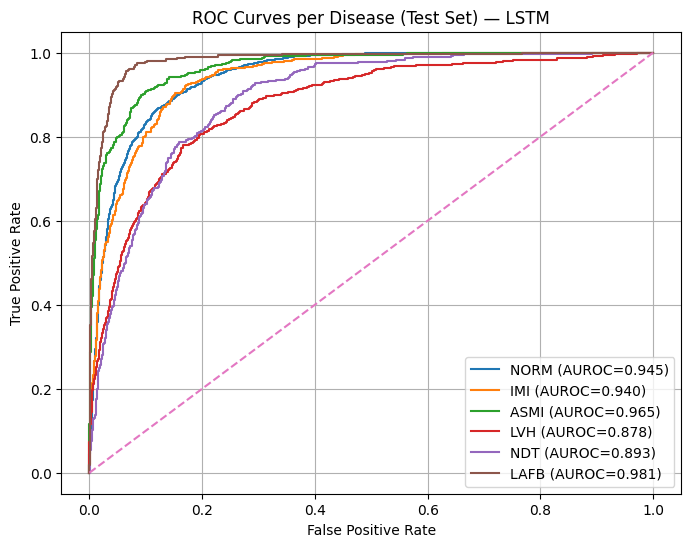

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))
for i, cls in enumerate(classes):
    y_true_c = te_y[:, i].astype(int)
    y_score_c = te_probs[:, i]

    if len(np.unique(y_true_c)) < 2:
        print(f"{cls}: ROC undefined (only one label present).")
        continue

    fpr, tpr, _ = roc_curve(y_true_c, y_score_c)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls} (AUROC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves per Disease (Test Set) — LSTM")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


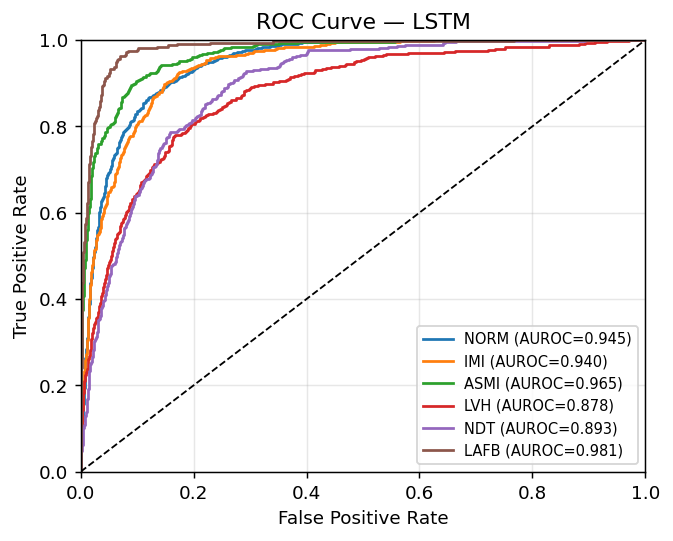

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(5.2, 4.2), dpi=132)   # same as your CNN setting
ax = plt.gca()

# Force identical axis range and remove padding
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)
ax.margins(x=0, y=0)

for i, cls in enumerate(classes):
    y_true_c = te_y[:, i].astype(int)
    y_score_c = te_probs[:, i]

    # Skip if ROC is undefined
    if len(np.unique(y_true_c)) < 2:
        print(f"{cls}: ROC undefined (only one label present).")
        continue

    fpr, tpr, _ = roc_curve(y_true_c, y_score_c)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=1.5, label=f"{cls} (AUROC={roc_auc:.3f})")

# Diagonal reference line
ax.plot([0, 1], [0, 1], "k--", lw=1)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — LSTM")
ax.legend(loc="lower right", fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# If saving for paper (recommended):
# plt.savefig("LSTM_ROC.png", dpi=132, bbox_inches="tight")
